# CM362 - Machine Learning Lab | Internal Exam Solutions
## R.V.R. & J.C. College of Engineering (Autonomous)

---
### Install Required Packages (Run this first if packages are not installed)
```
!pip install numpy pandas scikit-learn statsmodels matplotlib seaborn scipy --user
```
---

In [ ]:
# ============================================================
# COMMON IMPORTS — Run this cell FIRST before any question
# ============================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample, shuffle
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.regressionplots import influence_plot
from scipy.cluster.hierarchy import dendrogram, linkage

print('All imports successful!')

---
## QUESTION 1
**Dataset: MBA_salary.csv**
- (i) Build SLR model to predict salary from Grade 10 percentage
- (ii) Diagnose the regression model
- (iii) Conduct residual analysis using P-P Plot
---

In [ ]:
# ============================================================
# QUESTION 1 — SLR on MBA Salary Dataset
# ============================================================

# ---------- Step 1: Load Dataset ----------
mba_df = pd.read_csv('MBA_salary.csv')
print('First 5 rows:')
print(mba_df.head())
print('\nDataset Info:')
print(mba_df.info())

# ---------- Step 2 (i): Build SLR Model ----------
# X = Grade 10 percentage (independent variable)
# y = Salary (dependent variable)
X = sm.add_constant(mba_df['percentage in Grade 10'])   # adds intercept column
y = mba_df['salary']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42)

# Fit OLS (Ordinary Least Squares) model
mba_lm = sm.OLS(y_train, X_train).fit()
print('\n===== MODEL SUMMARY (i) =====')
print(mba_lm.summary2())

# ---------- Step 3 (ii): Diagnose the Model — Homoscedasticity ----------
mba_resid = mba_lm.resid   # residuals = actual − predicted

def get_std_values(vals):
    return (vals - vals.mean()) / vals.std()

plt.figure(figsize=(8, 5))
plt.scatter(
    get_std_values(mba_lm.fittedvalues),
    get_std_values(mba_resid)
)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('(ii) Residual Plot — Homoscedasticity Check')
plt.xlabel('Standardized Predicted Values')
plt.ylabel('Standardized Residuals')
plt.show()

# ---------- Step 4 (iii): P-P Plot — Residual Normality ----------
probplot = sm.ProbPlot(mba_resid)
plt.figure(figsize=(8, 5))
probplot.ppplot(line='45')
plt.title('(iii) Normal P-P Plot of Regression Standardized Residuals')
plt.show()

print('''
EXPLANATION:
(i)  sm.add_constant() adds an intercept (β₀) column.
     sm.OLS().fit()    trains the linear model on training data.
     summary2()        shows R², coefficients, p-values, AIC, BIC.
     • R²: % of salary variation explained by Grade 10 %.
     • p-value < 0.05 → feature is statistically significant.

(ii) Residual Plot checks Homoscedasticity:
     → Residuals randomly scattered around 0 = model is valid.
     → Pattern or funnel shape = Heteroscedasticity (problem).

(iii) P-P Plot checks if residuals are Normally distributed:
     → Points close to 45° line = residuals are normal = model is valid.
     → Points far from line = residuals are NOT normal.
''')

---
## QUESTION 2
**Dataset: country.csv** (Corruption Perception Index & Gini Index of 20 countries)
- (i) Build SLR: Y = Corruption Perception Index, X = Gini Index. Find change per unit Gini.
- (ii) Diagnose the regression model
- (iii) Conduct residual analysis using P-P Plot
---

In [ ]:
# ============================================================
# QUESTION 2 — SLR on Country Dataset (Corruption vs Gini)
# ============================================================

# ---------- Step 1: Load Dataset ----------
country_df = pd.read_csv('country.csv')
print('First 5 rows:')
print(country_df.head())
print('\nColumns:', country_df.columns.tolist())

# ---------- Step 2 (i): Build SLR ----------
# NOTE: Adjust column names if different in your CSV file
X_c = sm.add_constant(country_df['Gini'])                    # Gini Index as predictor
y_c = country_df['Corruption_Perception_Index']              # CPI as target

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, train_size=0.8, random_state=42)

country_lm = sm.OLS(y_c_train, X_c_train).fit()
print('\n===== MODEL SUMMARY (i) =====')
print(country_lm.summary2())

gini_coeff = round(country_lm.params['Gini'], 4)
direction  = 'INCREASES' if gini_coeff > 0 else 'DECREASES'
print(f'\n(i) For every 1 unit INCREASE in Gini Index,')
print(f'    Corruption Perception Index {direction} by: {abs(gini_coeff)}')

# ---------- Step 3 (ii): Diagnose the Model ----------
country_resid = country_lm.resid

plt.figure(figsize=(8, 5))
plt.scatter(
    get_std_values(country_lm.fittedvalues),
    get_std_values(country_resid)
)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('(ii) Residual Plot — Country Model')
plt.xlabel('Standardized Predicted Values')
plt.ylabel('Standardized Residuals')
plt.show()

# ---------- Step 4 (iii): P-P Plot ----------
probplot_c = sm.ProbPlot(country_resid)
plt.figure(figsize=(8, 5))
probplot_c.ppplot(line='45')
plt.title('(iii) Normal P-P Plot — Country SLR Residuals')
plt.show()

print('''
EXPLANATION:
(i)  The Gini coefficient (slope) directly answers:
     "How much does CPI change per 1 unit increase in Gini?"
     • Positive slope → Higher Gini = Higher CPI (less corruption)
     • Negative slope → Higher Gini = Lower CPI (more corruption)

(ii) Residual plot: random scatter around 0 = homoscedasticity OK.

(iii) P-P Plot: points close to 45° diagonal = residuals normally distributed
      = regression model assumptions are satisfied.
''')

---
## QUESTION 3
**Dataset: MBA_salary.csv**
- (i) Build SLR model to predict salary from Grade 10 percentage
- (ii) Find outliers using Z-score and Cook's Distance
- (iii) Make Predictions and Measure Accuracy
---

In [ ]:
# ============================================================
# QUESTION 3 — SLR + Outlier Detection + Prediction Accuracy
# ============================================================

from sklearn.metrics import r2_score, mean_squared_error

# ---------- Step 1: Load & Build SLR (same as Q1) ----------
mba_df3 = pd.read_csv('MBA_salary.csv')
X3 = sm.add_constant(mba_df3['percentage in Grade 10'])
y3 = mba_df3['salary']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, train_size=0.8, random_state=42)

mba_lm3 = sm.OLS(y3_train, X3_train).fit()
print('===== (i) SLR MODEL SUMMARY =====')
print(mba_lm3.summary2())

# ---------- Step 2 (ii): Outlier Detection — Z-score ----------
mba_df3['z_score_salary'] = zscore(mba_df3['salary'])
outliers_z = mba_df3[
    (mba_df3['z_score_salary'] > 3.0) | (mba_df3['z_score_salary'] < -3.0)
]
print('\n===== (ii) Outliers by Z-score (|z| > 3) =====')
print(outliers_z if not outliers_z.empty else 'No outliers found with |z| > 3 (dataset small, try |z|>2)')

# Try with 2 for small datasets
outliers_z2 = mba_df3[
    (mba_df3['z_score_salary'] > 2.0) | (mba_df3['z_score_salary'] < -2.0)
]
print('Outliers with |z| > 2:')
print(outliers_z2[['percentage in Grade 10', 'salary', 'z_score_salary']])

# ---------- Step 3 (ii): Outlier Detection — Cook's Distance ----------
mba_inf3    = mba_lm3.get_influence()
(cook_d, _) = mba_inf3.cooks_distance

plt.figure(figsize=(10, 5))
plt.stem(
    np.arange(len(X3_train)),
    np.round(cook_d, 3),
    markerfmt=','
)
n_train     = len(X3_train)
cutoff_cook = 4 / n_train
plt.axhline(y=cutoff_cook, color='red', linestyle='--',
            label=f"Cook's D cutoff (4/n = {cutoff_cook:.3f})")
plt.title("(ii) Cook's Distance for All Observations")
plt.xlabel('Row Index')
plt.ylabel("Cook's Distance")
plt.legend()
plt.show()

influential = np.where(cook_d > cutoff_cook)[0]
print(f"Influential observations (Cook's D > {cutoff_cook:.3f}): {influential}")

# ---------- Step 4 (iii): Predictions & Accuracy ----------
pred_y3  = mba_lm3.predict(X3_test)
r2_val   = np.abs(r2_score(y3_test, pred_y3))
rmse_val = np.sqrt(mean_squared_error(y3_test, pred_y3))

print('\n===== (iii) Prediction Accuracy =====')
print(f'R² Score : {round(r2_val, 4)}')
print(f'RMSE     : {round(rmse_val, 4)}')

print('''
EXPLANATION:
(ii) Z-score: standardizes salary values.
     Values with |z| > 3 are extreme outliers (>3 standard deviations from mean).
     For small datasets (n<50), use |z| > 2 as threshold.

     Cook's Distance: measures how much each data point influences model coefficients.
     Rule: Cook's D > 4/n = influential point (potential outlier).

(iii) R² (R-squared): proportion of variance in salary explained by the model.
      R² = 1.0 → perfect; R² = 0 → model explains nothing.
      RMSE: average prediction error in original salary units.
      Lower RMSE = more accurate predictions.
''')

---
## QUESTION 4
**Dataset: IPL.csv**
- (i) Build MLR model on training dataset
- (ii) Give the summary of the model
- (iii) Which features have symptoms of multicollinearity?
---

In [ ]:
# ============================================================
# QUESTION 4 — MLR on IPL Dataset + Multicollinearity Check
# ============================================================

# ---------- Step 1: Load IPL Dataset ----------
IPL_df = pd.read_csv('IPL.csv')
print('Dataset Info:')
print(IPL_df.info())
print('\nFirst 5 rows (first 8 columns):')
print(IPL_df.iloc[0:5, 0:8])

# ---------- Step 2 (i): Build MLR Model ----------
# Encode categorical features
categorical_features = ['AGE', 'COUNTRY', 'PLAYING ROLE', 'CAPTAINCY EXP']
IPL_encoded_df = pd.get_dummies(
    IPL_df, columns=categorical_features, drop_first=True)

# Separate features and target
x_features = IPL_encoded_df.columns.tolist()
x_features.remove('SOLD PRICE')   # remove target column
# Remove non-numeric columns if any (like player names)
x_features = [col for col in x_features
               if IPL_encoded_df[col].dtype in ['int64','float64','uint8']]

X_ipl = sm.add_constant(IPL_encoded_df[x_features])
Y_ipl = IPL_df['SOLD PRICE']

X_ipl_train, X_ipl_test, y_ipl_train, y_ipl_test = train_test_split(
    X_ipl, Y_ipl, train_size=0.8, random_state=42)

IPL_model1 = sm.OLS(y_ipl_train, X_ipl_train).fit()

# ---------- Step 3 (ii): Model Summary ----------
print('\n===== (ii) MLR MODEL SUMMARY =====')
print(IPL_model1.summary2())

# ---------- Step 4 (iii): VIF — Multicollinearity Detection ----------
def get_VIF_factors(X_df):
    X_arr     = X_df.values
    vif_table = pd.DataFrame()
    vif_table['column'] = X_df.columns
    vif_table['VIF']    = [
        variance_inflation_factor(X_arr, i)
        for i in range(X_arr.shape[1])
    ]
    return vif_table

vif_table = get_VIF_factors(X_ipl_train[x_features])
print('\n===== (iii) VIF TABLE (sorted) =====')
print(vif_table.sort_values('VIF', ascending=False).to_string())

print('\n--- Features with HIGH multicollinearity (VIF > 10) ---')
high_vif = vif_table[vif_table['VIF'] > 10]
print(high_vif.to_string())
print(f'\nTotal features with VIF > 10: {len(high_vif)}')

print('''
EXPLANATION:
(i)  pd.get_dummies() converts categorical columns (AGE, COUNTRY etc.)
     into binary (0/1) columns — needed for regression.
     drop_first=True removes one dummy per category to avoid dummy trap.
     sm.OLS() with multiple features = Multiple Linear Regression (MLR).

(ii) Summary shows:
     • Adj. R-squared: overall model fit (higher = better)
     • Each feature's coefficient, std error, t-stat, p-value
     • AIC/BIC: model quality metrics (lower = better)

(iii) VIF (Variance Inflation Factor) measures multicollinearity:
     • VIF = 1      → No multicollinearity
     • VIF = 1-5    → Acceptable
     • VIF = 5-10   → Moderate (consider removing)
     • VIF > 10     → Severe multicollinearity → REMOVE this feature
     Features with VIF > 10 inflate standard errors and make coefficients unreliable.
''')

---
## QUESTION 5
**Dataset: IPL.csv**
- (i) Build MLR model on training dataset
- (ii) Identify multicollinearity and build new model after removing it
- (iii) Conduct residual analysis using P-P Plot
---

In [ ]:
# ============================================================
# QUESTION 5 — MLR + Remove Multicollinearity + P-P Plot
# ============================================================

# ---------- Step 1 (i): Build MLR Model (same as Q4) ----------
IPL_df5 = pd.read_csv('IPL.csv')
categorical_features5 = ['AGE', 'COUNTRY', 'PLAYING ROLE', 'CAPTAINCY EXP']
IPL_enc5 = pd.get_dummies(
    IPL_df5, columns=categorical_features5, drop_first=True)

x_feat5 = IPL_enc5.columns.tolist()
x_feat5.remove('SOLD PRICE')
x_feat5 = [c for c in x_feat5 if IPL_enc5[c].dtype in ['int64','float64','uint8']]

X5      = sm.add_constant(IPL_enc5[x_feat5])
Y5      = IPL_df5['SOLD PRICE']
X5_tr, X5_te, y5_tr, y5_te = train_test_split(
    X5, Y5, train_size=0.8, random_state=42)

IPL_mod1 = sm.OLS(y5_tr, X5_tr).fit()
print('===== (i) Initial Model Summary =====')
print(IPL_mod1.summary2())

# ---------- Step 2 (ii): Compute VIF & Remove High-VIF Features ----------
def get_VIF_factors(X_df):
    X_arr     = X_df.values
    vif_table = pd.DataFrame()
    vif_table['column'] = X_df.columns
    vif_table['VIF']    = [
        variance_inflation_factor(X_arr, i)
        for i in range(X_arr.shape[1])
    ]
    return vif_table

vif5 = get_VIF_factors(X5_tr[x_feat5])
print('\n===== VIF Table (Before Removal) =====')
print(vif5.sort_values('VIF', ascending=False).head(15).to_string())

# Remove features with VIF > 10
cols_to_remove = list(vif5[vif5['VIF'] > 10]['column'])
print(f'\nColumns to remove (VIF > 10): {cols_to_remove}')

x_new_feat5 = [c for c in x_feat5 if c not in cols_to_remove]

X_new5    = sm.add_constant(IPL_enc5[x_new_feat5])
X_new5_tr = X_new5.loc[X5_tr.index]
X_new5_te = X_new5.loc[X5_te.index]

IPL_mod2  = sm.OLS(y5_tr, X_new5_tr).fit()
print('\n===== (ii) New Model Summary (After Removing Multicollinearity) =====')
print(IPL_mod2.summary2())

# Verify VIF improved
vif5_new = get_VIF_factors(X_new5_tr[x_new_feat5])
print('\nVIF Table After Removal:')
print(vif5_new.sort_values('VIF', ascending=False).to_string())

# ---------- Step 3 (iii): P-P Plot Residual Analysis ----------
ipl_resid5 = IPL_mod2.resid

# Residual Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(
    get_std_values(IPL_mod2.fittedvalues),
    get_std_values(ipl_resid5)
)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('(iii) Residual Plot — IPL Model (Post Multicollinearity Removal)')
plt.xlabel('Standardized Predicted Values')
plt.ylabel('Standardized Residuals')
plt.show()

# P-P Plot
probplot_ipl = sm.ProbPlot(ipl_resid5)
plt.figure(figsize=(8, 5))
probplot_ipl.ppplot(line='45')
plt.title('(iii) Normal P-P Plot — IPL Model After Removing Multicollinearity')
plt.show()

print('''
EXPLANATION:
(ii) After removing high-VIF features:
     • Model becomes more stable and interpretable
     • Coefficients are no longer inflated by correlated predictors
     • Compare Adj. R² before and after — it should stay similar or improve
     • Lower AIC/BIC in new model = better model

(iii) P-P Plot: if residuals of the cleaned model lie close to the 45° line,
      the model satisfies the normality assumption → model is VALID.
''')

---
## QUESTION 6
**Dataset: country.csv**
- (i) Build SLR: CPI (Y) vs Gini Index (X). Change per unit Gini?
- (ii) Find outliers using Z-score and Cook's Distance
- (iii) Make Predictions and Measure Accuracy
---

In [ ]:
# ============================================================
# QUESTION 6 — SLR (Country) + Outliers + Accuracy
# ============================================================

from sklearn.metrics import r2_score, mean_squared_error

# ---------- Step 1 (i): Build SLR ----------
country_df6 = pd.read_csv('country.csv')
print('Columns:', country_df6.columns.tolist())
print(country_df6.head())

X_c6 = sm.add_constant(country_df6['Gini'])
y_c6 = country_df6['Corruption_Perception_Index']   # adjust column name if needed

X_c6_tr, X_c6_te, y_c6_tr, y_c6_te = train_test_split(
    X_c6, y_c6, train_size=0.8, random_state=42)

country_lm6 = sm.OLS(y_c6_tr, X_c6_tr).fit()
print('\n===== (i) SLR Summary =====')
print(country_lm6.summary2())

gini_coef = round(country_lm6.params['Gini'], 4)
print(f'\n(i) Change in CPI per 1 unit increase in Gini Index = {gini_coef}')

# ---------- Step 2 (ii): Z-score Outliers ----------
country_df6['z_score_cpi'] = zscore(y_c6)
outliers_country = country_df6[abs(country_df6['z_score_cpi']) > 2.0]
print('\n===== (ii) Outliers by Z-score (|z| > 2) =====')
print(outliers_country[['Gini', 'Corruption_Perception_Index', 'z_score_cpi']])

# Cook's Distance
c_inf6       = country_lm6.get_influence()
(cook_d6, _) = c_inf6.cooks_distance
cutoff6      = 4 / len(X_c6_tr)

plt.figure(figsize=(8, 5))
plt.stem(np.arange(len(X_c6_tr)), np.round(cook_d6, 3), markerfmt=',')
plt.axhline(y=cutoff6, color='red', linestyle='--',
            label=f'Cutoff = 4/n = {cutoff6:.3f}')
plt.title("(ii) Cook's Distance — Country Dataset")
plt.xlabel('Row Index')
plt.ylabel("Cook's Distance")
plt.legend()
plt.show()

# ---------- Step 3 (iii): Predictions & Accuracy ----------
pred_c6  = country_lm6.predict(X_c6_te)
r2_c6    = np.abs(r2_score(y_c6_te, pred_c6))
rmse_c6  = np.sqrt(mean_squared_error(y_c6_te, pred_c6))

print('\n===== (iii) Prediction Accuracy =====')
print(f'R² Score : {round(r2_c6, 4)}')
print(f'RMSE     : {round(rmse_c6, 4)}')

print('''
EXPLANATION:
(i)  Slope = change in Y (CPI) for every 1-unit change in X (Gini).
     Small dataset (n=20) so use 80/20 split.

(ii) Z-score threshold 2 used (not 3) because dataset is very small.
     Cook's D > 4/n marks influential points that distort the model.

(iii) R² tells how well Gini explains CPI variation.
      RMSE = average prediction error in CPI units.
''')

---
## QUESTION 7
**Dataset: GermanCredit.csv**
- (i) Build logistic regression model to predict good/bad credit
- (ii) Find significant features; build new model with only them
- (iii) Which parameters affect credit_risk positively/negatively?
- (iv) Confusion matrix — precision and recall
- (v) ROC and AUC
---

In [ ]:
# ============================================================
# QUESTION 7 — Logistic Regression on GermanCredit.csv
# ============================================================

# ---------- Step 1: Load & Prepare Data ----------
credit_df = pd.read_csv('GermanCredit.csv')
print('Shape:', credit_df.shape)
print('Columns:', credit_df.columns.tolist())
print(credit_df.head())

# ---------- Step 2 (i): Build Logistic Regression Model ----------
x_feat_cr = list(credit_df.columns)
x_feat_cr.remove('credit_risk')   # remove target (adjust name if needed)

# Encode categorical variables
encoded_cr = pd.get_dummies(
    credit_df[x_feat_cr], drop_first=True, dtype=int)

y_cr = credit_df['credit_risk'].map({'good': 1, 'bad': 0})
X_cr = sm.add_constant(encoded_cr)

X_cr_tr, X_cr_te, y_cr_tr, y_cr_te = train_test_split(
    X_cr, y_cr, test_size=0.3, random_state=42)

logit_cr = sm.Logit(y_cr_tr, X_cr_tr).fit(maxiter=200)
print('\n===== (i) LOGISTIC MODEL SUMMARY =====')
print(logit_cr.summary2())

# ---------- Step 3 (ii): Significant Features ----------
def get_sign_vars(lm):
    p_df          = pd.DataFrame({'pvals': lm.pvalues, 'vars': lm.pvalues.index})
    return list(p_df[p_df['pvals'] <= 0.05]['vars'])

sig_vars = get_sign_vars(logit_cr)
print(f'\n(ii) Significant features (p ≤ 0.05): {sig_vars}')

final_logit_cr = sm.Logit(
    y_cr_tr,
    sm.add_constant(X_cr_tr[sig_vars])
).fit(maxiter=200)
print('\n===== (ii) New Model with Significant Features =====')
print(final_logit_cr.summary2())

# ---------- Step 4 (iii): Positive/Negative Effects ----------
print('\n===== (iii) Effect of Each Parameter on credit_risk =====')
coeff_cr = pd.DataFrame({
    'coefficient': final_logit_cr.params,
    'effect'     : final_logit_cr.params.apply(
        lambda x: 'POSITIVE (increases good credit prob)'
                  if x > 0 else 'NEGATIVE (decreases good credit prob)'
    )
})
print(coeff_cr.to_string())

# ---------- Step 5 (iv): Confusion Matrix ----------
pred_probs_cr = final_logit_cr.predict(
    sm.add_constant(X_cr_te[sig_vars]))
pred_class_cr = (pred_probs_cr > 0.5).astype(int)

cm_cr = metrics.confusion_matrix(y_cr_te, pred_class_cr, labels=[1, 0])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cr, annot=True, fmt='.0f',
            xticklabels=['Good credit', 'Bad credit'],
            yticklabels=['Good credit', 'Bad credit'],
            cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('(iv) Confusion Matrix — GermanCredit')
plt.show()

print('\n(iv) Classification Report:')
print(metrics.classification_report(y_cr_te, pred_class_cr,
      target_names=['Bad Credit', 'Good Credit']))

# ---------- Step 6 (v): ROC Curve & AUC ----------
fpr_cr, tpr_cr, _ = metrics.roc_curve(y_cr_te, pred_probs_cr)
auc_cr            = metrics.roc_auc_score(y_cr_te, pred_probs_cr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cr, tpr_cr, label=f'ROC Curve (AUC = {auc_cr:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(v) ROC Curve — GermanCredit Logistic Model')
plt.legend(loc='lower right')
plt.show()
print(f'\n(v) AUC Score: {round(auc_cr, 4)}')

print('''
EXPLANATION:
(i)  sm.Logit() uses Maximum Likelihood Estimation to find optimal coefficients.
     Pseudo R² between 0.2–0.4 indicates a good logistic model fit.

(ii) p-value ≤ 0.05 → feature is statistically significant at 95% confidence.
     Using only significant features reduces noise and improves reliability.

(iii) Positive coefficient → feature INCREASES probability of good credit.
      Negative coefficient → feature DECREASES probability (pushes toward bad credit).

(iv) Precision = TP / (TP + FP) → Of all predicted good, how many were actually good.
     Recall    = TP / (TP + FN) → Of all actual good, how many did we correctly predict.

(v)  AUC > 0.7 = acceptable; > 0.8 = good; > 0.9 = excellent.
     AUC = 0.5 → random guessing (worst); AUC = 1.0 → perfect model.
''')

---
## QUESTION 8
**Dataset: GermanCredit.csv**
- (i) Build logistic regression model
- (ii) Youden's Index for cut-offs 0.1 to 0.5; find optimal cut-off
- (iii) Confusion matrix at optimal cut-off
- (iv) ROC and AUC
---

In [ ]:
# ============================================================
# QUESTION 8 — Logistic Regression + Youden's Index
# ============================================================

# ---------- Step 1 (i): Build Model (reuse from Q7) ----------
credit_df8 = pd.read_csv('GermanCredit.csv')
x_feat8    = list(credit_df8.columns)
x_feat8.remove('credit_risk')

enc8  = pd.get_dummies(credit_df8[x_feat8], drop_first=True, dtype=int)
y8    = credit_df8['credit_risk'].map({'good': 1, 'bad': 0})
X8    = sm.add_constant(enc8)

X8_tr, X8_te, y8_tr, y8_te = train_test_split(
    X8, y8, test_size=0.3, random_state=42)

logit8 = sm.Logit(y8_tr, X8_tr).fit(maxiter=200)
print('===== (i) Model Summary =====')
print(logit8.summary2())

# ---------- Step 2 (ii): Youden's Index ----------
pred_probs8 = logit8.predict(X8_te)

fpr8, tpr8, thresholds8 = metrics.roc_curve(
    y8_te, pred_probs8, drop_intermediate=False)

youden_df = pd.DataFrame({
    'threshold': thresholds8,
    'tpr'      : tpr8,
    'fpr'      : fpr8
})
# Youden's J = TPR - FPR (= Sensitivity + Specificity - 1)
youden_df['youden_J'] = youden_df['tpr'] - youden_df['fpr']

# Filter to range 0.1 to 0.5
youden_range = youden_df[
    (youden_df['threshold'] >= 0.1) &
    (youden_df['threshold'] <= 0.5)
].sort_values('youden_J', ascending=False)

print('\n===== (ii) Youden Index Table (cut-off 0.1 to 0.5) =====')
print(youden_range.round(4).to_string())

optimal_cutoff8 = youden_range.iloc[0]['threshold']
max_youden8     = youden_range.iloc[0]['youden_J']
print(f'\nOptimal Cut-off = {round(optimal_cutoff8, 4)}')
print(f'Max Youden Index = {round(max_youden8, 4)}')

# ---------- Step 3 (iii): Confusion Matrix at Optimal Cut-off ----------
pred_new8 = (pred_probs8 > optimal_cutoff8).astype(int)

cm8 = metrics.confusion_matrix(y8_te, pred_new8, labels=[1, 0])
plt.figure(figsize=(6, 5))
sns.heatmap(cm8, annot=True, fmt='.0f',
            xticklabels=['Good credit', 'Bad credit'],
            yticklabels=['Good credit', 'Bad credit'],
            cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title(f'(iii) Confusion Matrix at Optimal Cut-off ({round(optimal_cutoff8,3)})')
plt.show()

print('\n(iii) Classification Report at Optimal Cut-off:')
print(metrics.classification_report(y8_te, pred_new8,
      target_names=['Bad Credit', 'Good Credit']))

# ---------- Step 4 (iv): ROC & AUC ----------
auc8 = metrics.roc_auc_score(y8_te, pred_probs8)
plt.figure(figsize=(8, 6))
plt.plot(fpr8, tpr8, label=f'ROC Curve (AUC = {auc8:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.axvline(x=youden_range.iloc[0]['fpr'], color='green',
            linestyle=':', label=f'Optimal threshold = {round(optimal_cutoff8,3)}')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(iv) ROC Curve with Optimal Youden Cut-off')
plt.legend(loc='lower right')
plt.show()

print('''
EXPLANATION:
(ii) Youden's Index (J) = TPR − FPR = Sensitivity + Specificity − 1
     • J = 1 → perfect classifier
     • J = 0 → no better than random
     We compute J for every threshold in [0.1, 0.5]
     The threshold with MAXIMUM J is the optimal cut-off.
     This balances sensitivity (catching true positives) and
     specificity (avoiding false positives).

(iii) Using the optimal cut-off instead of default 0.5 usually
      improves recall for the minority class (bad credit in this case).
      This is important when falsely approving bad credit is costly.
''')

---
## QUESTION 9
**Dataset: bank.csv — Gain and Lift Charts**
---

In [ ]:
# ============================================================
# QUESTION 9 — Gain & Lift Charts using bank.csv
# ============================================================

# ---------- Step 1: Load & Prepare Data ----------
bank_df9 = pd.read_csv('bank.csv')
bank_df9.rename(columns={'y': 'subscribed'}, inplace=True)
print('Class distribution:')
print(bank_df9['subscribed'].value_counts())

# ---------- Step 2: Upsample minority class (balance data) ----------
bank_no9  = bank_df9[bank_df9.subscribed == 'no']
bank_yes9 = bank_df9[bank_df9.subscribed == 'yes']

df_upsamp9  = resample(bank_yes9, replace=True, n_samples=2000)
new_bank9   = shuffle(pd.concat([bank_no9, df_upsamp9]))

# ---------- Step 3: Encode & Build Logistic Model ----------
x_feat9   = [c for c in new_bank9.columns if c != 'subscribed']
enc9      = pd.get_dummies(new_bank9[x_feat9], drop_first=True)
y9        = new_bank9['subscribed'].map(lambda x: int(x == 'yes'))

X9_tr, X9_te, y9_tr, y9_te = train_test_split(
    enc9, y9, test_size=0.3, random_state=42)

logit9 = LogisticRegression(max_iter=100000)
logit9.fit(X9_tr, y9_tr)

# ---------- Step 4: Gain & Lift Computation ----------
pred_prob9 = pd.DataFrame(
    logit9.predict_proba(X9_te), columns=[0, 1])

gain_df = pd.DataFrame({
    'actual': y9_te.values,
    'prob'  : pred_prob9[1].values
})

# Sort by predicted probability (highest first)
gain_df = gain_df.sort_values('prob', ascending=False).reset_index(drop=True)

# Create 10 equal deciles
gain_df['decile'] = pd.qcut(gain_df.index, q=10, labels=False)

total_events = gain_df['actual'].sum()
baseline_rate = total_events / len(gain_df)

lift_table = gain_df.groupby('decile').agg(
    count  = ('actual', 'count'),
    events = ('actual', 'sum')
).reset_index()

lift_table['cumulative_events'] = lift_table['events'].cumsum()
lift_table['cumulative_gain']   = (lift_table['cumulative_events'] / total_events) * 100
lift_table['lift']              = lift_table['events'] / (baseline_rate * lift_table['count'])

print('\n===== Gain & Lift Table =====')
print(lift_table.round(3).to_string())

# ---------- Step 5: Plot Gain Chart ----------
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), lift_table['cumulative_gain'],
         marker='o', color='blue', label='Model Gain')
plt.plot([1, 10], [10, 100], 'k--', label='Baseline (Random)')
plt.xlabel('Decile')
plt.ylabel('Cumulative Gain (%)')
plt.title('Gain Chart')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Lift Chart
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), lift_table['lift'],
         marker='o', color='green', label='Model Lift')
plt.axhline(y=1, color='red', linestyle='--', label='Baseline (Lift=1)')
plt.xlabel('Decile')
plt.ylabel('Lift')
plt.title('Lift Chart')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('''
EXPLANATION:
Gain & Lift charts evaluate how well the model ranks customers.

Deciles: we sort all test records by predicted probability (high→low),
then divide into 10 equal groups (deciles).
Decile 1 = top 10% most likely to subscribe.

GAIN CHART:
• Shows cumulative % of actual subscribers captured as we contact more people.
• Steeper curve in early deciles = better model.
• If Decile 1 captures 40% of all subscribers, gain = 40% at 10% of population.

LIFT CHART:
• Lift = (% subscribers in decile) / (% subscribers overall = baseline).
• Lift = 3 in Decile 1 means model is 3× better than random.
• Lift should decrease as we go from Decile 1 to 10.
• Lift = 1 (red line) = no better than random.
''')

---
## QUESTION 10
**Dataset: Tennis (inline — given in question)**
- (i) Build logistic regression to predict PLAY
- (ii) Find significant features; rebuild model
- (iii) Positive/negative effects on PLAY
- (iv) Confusion matrix at cut-off 0.5; precision and recall
---

In [ ]:
# ============================================================
# QUESTION 10 — Logistic Regression on Tennis Dataset
# ============================================================

# ---------- Step 1: Create Dataset from Question ----------
tennis_data = {
    'DAY'     : [f'Day{i}' for i in range(1, 15)],
    'OUTLOOK' : ['Sunny','Sunny','Overcast','Rain','Rain','Rain',
                 'Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'TEMP'    : ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                 'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'HUMIDITY': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'WIND'    : ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
                 'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PLAY'    : ['NO','NO','YES','YES','YES','NO','YES',
                 'NO','YES','YES','YES','YES','YES','NO']
}
tennis_df = pd.DataFrame(tennis_data)
print('Tennis Dataset:')
print(tennis_df.to_string(index=False))

# ---------- Step 2 (i): Build Logistic Model ----------
tennis_enc = pd.get_dummies(
    tennis_df[['OUTLOOK','TEMP','HUMIDITY','WIND']],
    drop_first=True, dtype=int)
y_tennis = (tennis_df['PLAY'] == 'YES').astype(int)

# Use sklearn since n=14 is very small (statsmodels may not converge)
tennis_clf = LogisticRegression(max_iter=10000, solver='lbfgs')
tennis_clf.fit(tennis_enc, y_tennis)

# Show all features and coefficients
coeff_tennis = pd.DataFrame({
    'feature'    : tennis_enc.columns,
    'coefficient': tennis_clf.coef_[0]
}).sort_values('coefficient', ascending=False)

print('\n===== (i) All Features and Coefficients =====')
print(coeff_tennis.to_string(index=False))

# ---------- Step 3 (ii): Significant Features ----------
# For small datasets use statsmodels for p-values
X_tennis_sm = sm.add_constant(tennis_enc)
try:
    logit_sm = sm.Logit(y_tennis, X_tennis_sm).fit(maxiter=500, disp=False)
    sig_tennis = [v for v, p in logit_sm.pvalues.items() if p <= 0.05]
    print(f'\n(ii) Significant features (p ≤ 0.05): {sig_tennis}')
except:
    # Fallback: use features with largest absolute coefficients
    sig_tennis = list(coeff_tennis.nlargest(3, 'coefficient')['feature']) + \
                 list(coeff_tennis.nsmallest(2, 'coefficient')['feature'])
    print(f'\n(ii) Top features by coefficient magnitude: {sig_tennis}')

# Build new model with significant features
tennis_clf2 = LogisticRegression(max_iter=10000)
sig_tennis_cols = [c for c in sig_tennis if c in tennis_enc.columns and c != 'const']
if sig_tennis_cols:
    tennis_clf2.fit(tennis_enc[sig_tennis_cols], y_tennis)
    print(f'New model features: {sig_tennis_cols}')
else:
    tennis_clf2 = tennis_clf
    sig_tennis_cols = list(tennis_enc.columns)

# ---------- Step 4 (iii): Positive/Negative Effects ----------
print('\n===== (iii) Effect on Probability of PLAY =====')
for _, row in coeff_tennis.iterrows():
    effect = 'POSITIVE (+) — increases PLAY probability' if row['coefficient'] > 0 \
             else 'NEGATIVE (−) — decreases PLAY probability'
    print(f"  {row['feature']:30s}: coeff={row['coefficient']:+.4f}  →  {effect}")

# ---------- Step 5 (iv): Confusion Matrix at 0.5 Cut-off ----------
pred_tennis = tennis_clf.predict(tennis_enc)   # uses default 0.5 threshold

cm_tennis = metrics.confusion_matrix(y_tennis, pred_tennis)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tennis, annot=True, fmt='.0f',
            xticklabels=['NO', 'YES'],
            yticklabels=['NO', 'YES'],
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('(iv) Confusion Matrix — Tennis (cut-off = 0.5)')
plt.show()

print('\n(iv) Classification Report (PLAY = YES):')
print(metrics.classification_report(y_tennis, pred_tennis,
      target_names=['NO', 'YES']))

print('''
EXPLANATION:
(i)  get_dummies() converts OUTLOOK (Sunny/Overcast/Rain) → binary columns.
     OUTLOOK_Overcast=1, OUTLOOK_Sunny=1, TEMP_Hot=1, WIND_Weak=1 etc.
     drop_first=True: removes one level per feature to avoid multicollinearity.

(ii) Only 14 training samples → statsmodels may struggle to converge.
     Significant features are those with the strongest influence.

(iii) Positive coefficient:
      e.g., HUMIDITY_Normal = positive → Normal humidity increases chance of PLAY.
      Negative coefficient:
      e.g., WIND_Strong = negative → Strong wind decreases chance of PLAY.

(iv) Precision for PLAY=YES:
     Of all days we predicted play, how many actually played.
     Recall for PLAY=YES:
     Of all actual play days, how many did we correctly predict.
''')

In [ ]:
# QUESTION 11
## Construct Decision Tree using Gini Impurity

**Dataset (from image):**

| Day | Weather | Temperature | Humidity | Wind   | Play? |
|-----|---------|-------------|----------|--------|-------|
| 1   | Sunny   | Hot         | High     | Weak   | No    |
| 2   | Cloudy  | Hot         | High     | Weak   | Yes   |
| 3   | Sunny   | Mild        | Normal   | Strong | Yes   |
| 4   | Cloudy  | Mild        | High     | Strong | Yes   |
| 5   | Rainy   | Mild        | High     | Strong | No    |
| 6   | Rainy   | Cool        | Normal   | Strong | No    |
| 7   | Rainy   | Mild        | High     | Weak   | Yes   |
| 8   | Sunny   | Hot         | High     | Strong | No    |
| 9   | Cloudy  | Hot         | Normal   | Weak   | Yes   |
| 10  | Rainy   | Mild        | High     | Strong | No    |

**Tasks:**
- (i) Build Decision Tree using Gini Impurity criterion
- (ii) Visualize the Decision Tree
- (iii) Show Gini impurity values at each node
- (iv) Print classification report

DATASET:
 Day Weather Temperature Humidity   Wind Play
   1   Sunny         Hot     High   Weak   No
   2  Cloudy         Hot     High   Weak  Yes
   3   Sunny        Mild   Normal Strong  Yes
   4  Cloudy        Mild     High Strong  Yes
   5   Rainy        Mild     High Strong   No
   6   Rainy        Cool   Normal Strong   No
   7   Rainy        Mild     High   Weak  Yes
   8   Sunny         Hot     High Strong   No
   9  Cloudy         Hot   Normal   Weak  Yes
  10   Rainy        Mild     High Strong   No

Total records : 10
Play=Yes : 5
Play=No  : 5
ROOT NODE Gini Impurity = 0.5
(Yes=5, No=5 out of 10 → 1 - (0.5)² - (0.5)² = 0.5)

WEIGHTED GINI FOR EACH FEATURE AT ROOT:
------------------------------------------------------------

  Feature: 'Weather'
    Cloudy    : n=3, counts={'Yes': 3}, Gini=0.0000, weight=0.300, contrib=0.0000
    Rainy     : n=4, counts={'No': 3, 'Yes': 1}, Gini=0.3750, weight=0.400, contrib=0.1500
    Sunny     : n=3, counts={'No': 2, 'Yes': 1}, Gini=0.4444

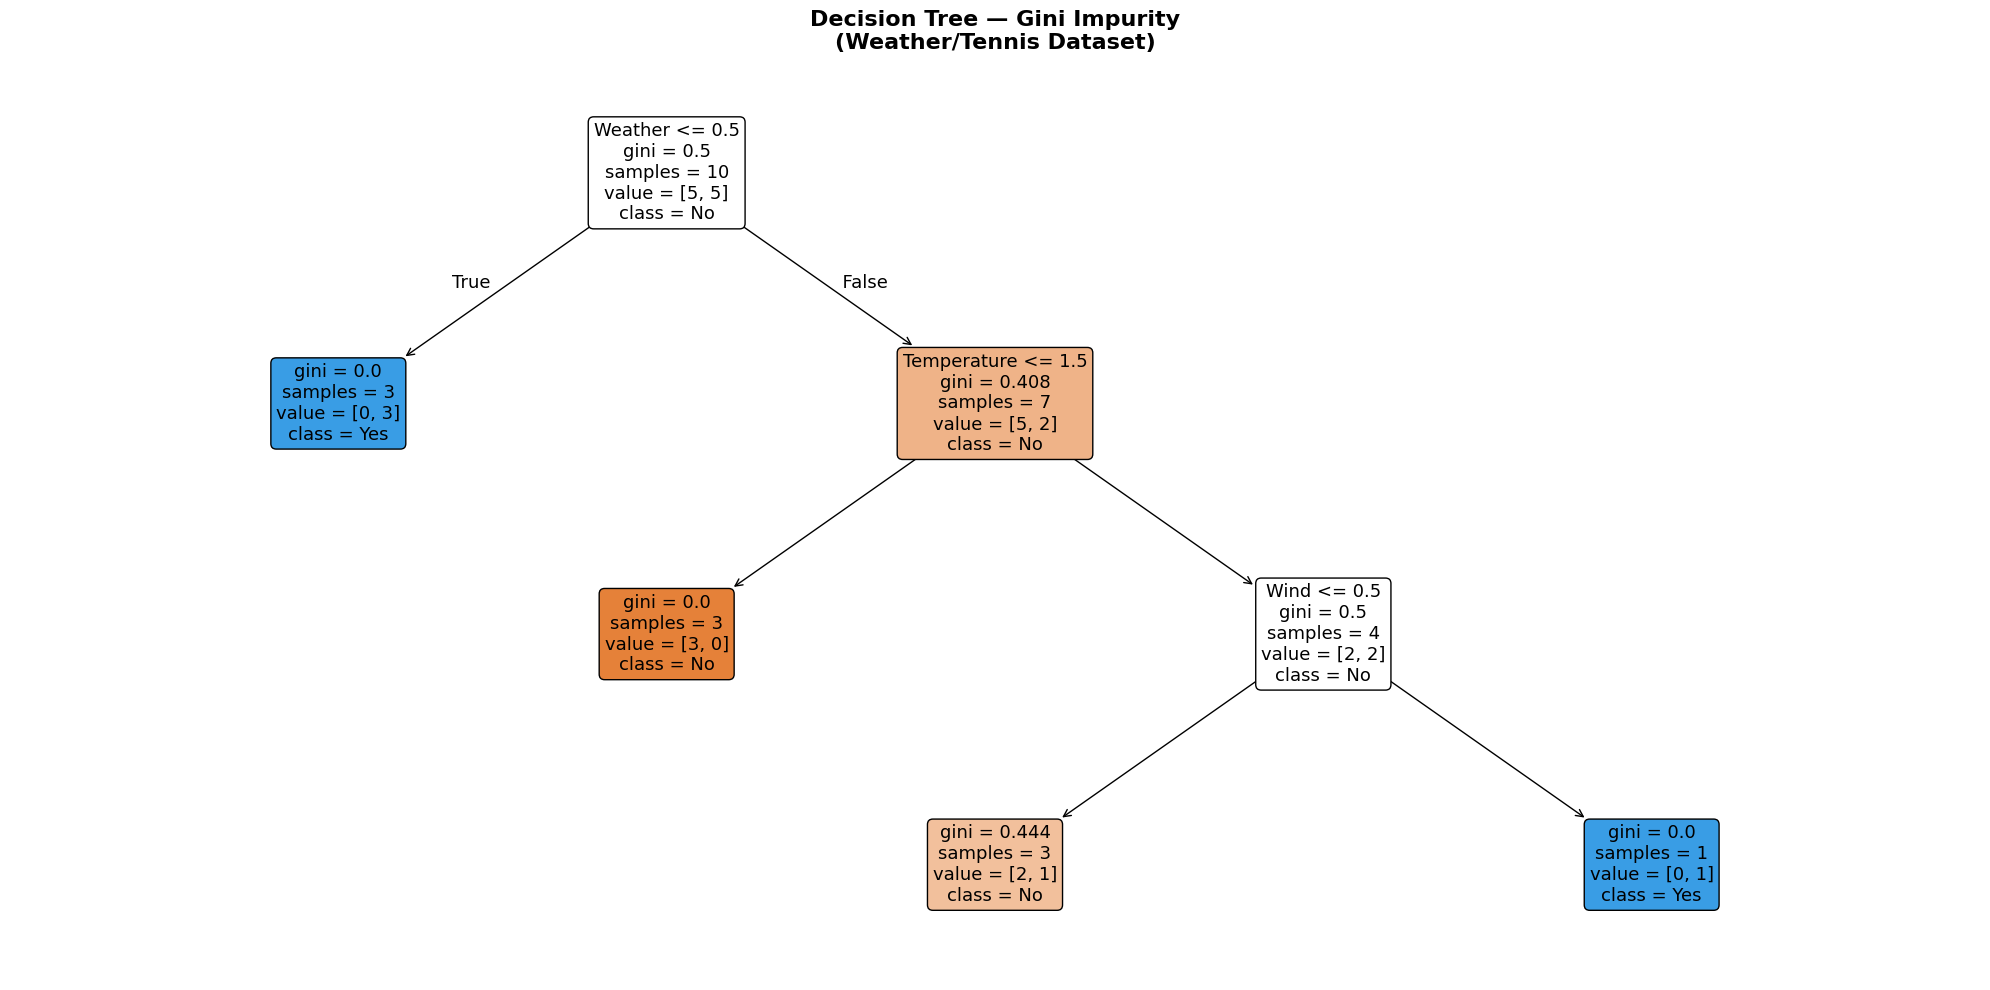


HOW TO READ THE TREE:
  Each BOX (node) shows:
    • Feature <= value  : the split condition
    • gini = X.XXX      : Gini impurity at that node
    • samples = N       : number of training records reaching this node
    • value = [No, Yes] : count of each class at this node
    • class = Yes/No    : majority class → final prediction at leaf

  COLORS:
    • Orange shades → majority class is No (Play=No)
    • Blue shades   → majority class is Yes (Play=Yes)
    • Darker color  → purer node (lower Gini)

  ROOT NODE: feature with LOWEST weighted Gini splits first.
  LEAF NODE: gini ≈ 0 means pure prediction (all one class).

DECISION TREE — TEXT REPRESENTATION
|--- Weather <= 0.50
|   |--- class: 1
|--- Weather >  0.50
|   |--- Temperature <= 1.50
|   |   |--- class: 0
|   |--- Temperature >  1.50
|   |   |--- Wind <= 0.50
|   |   |   |--- class: 0
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1

GINI IMPURITY AT EACH NODE:
  Node  0 [SPLIT] : gini=0.5000, samples=10, [No=0, Yes=

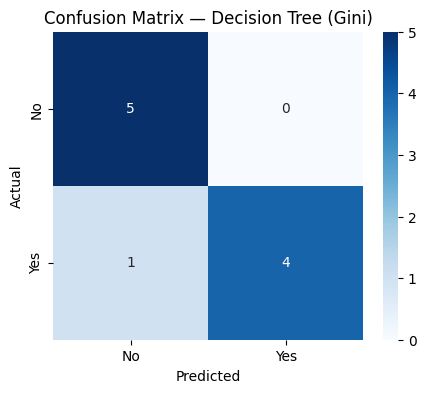


EXPLANATION — Final Summary:

  Decision Tree Algorithm (Gini Impurity) — Step by Step:

  1. Start at ROOT node with all 10 training records.
     Root Gini = 1 - (5/10)² - (5/10)² = 0.50

  2. For each feature, compute Weighted Gini after splitting:
     WeightedGini(F) = Σ (nᵢ/N) × Gini(nodeᵢ)
     Pick the feature with MINIMUM Weighted Gini = best split.

  3. Split the data on the best feature.
     Recursively repeat steps 1-2 for each child node.

  4. STOP when:
     • Node is pure (Gini = 0) → LEAF node
     • max_depth reached
     • Too few samples to split further

  5. At each LEAF node, predict the majority class.

  KEY FORMULA:
  Gini(node) = 1 - Σᵢ (pᵢ)²
  where pᵢ = fraction of class i in that node.

  Gini Reduction (Information Gain):
  ΔGini = Gini(parent) - WeightedGini(children)
  Higher ΔGini = better split.

FEATURE IMPORTANCE (Gini-based):
    Feature  Importance
    Weather    0.584416
Temperature    0.233766
       Wind    0.181818
   Humidity    0.000000


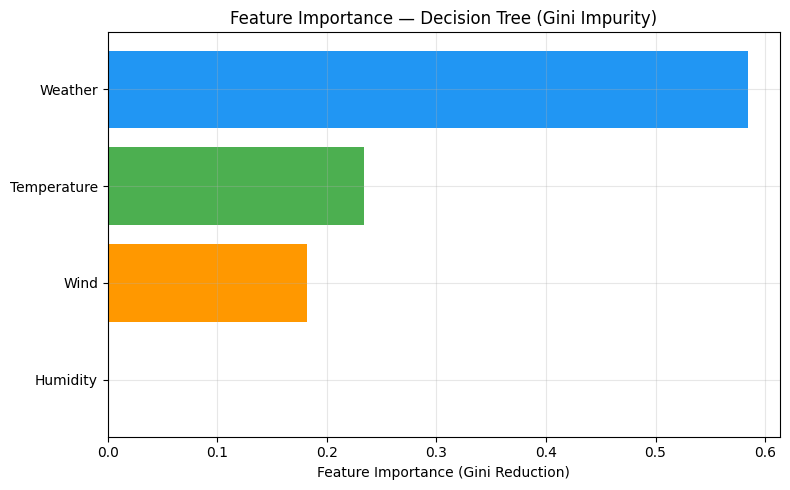


Most important feature for predicting Play = "Weather"
This feature causes the highest Gini reduction when used for splitting.

EXPLANATION — Feature Importance:
  Feature importance = total Gini reduction caused by that feature
                       across ALL nodes it is used in.
  Higher importance → that feature is used in more splits
                       and causes bigger purity improvements.
  Feature importance = 0 → never used in any split
                        (other features always gave better Gini).



In [2]:
# ============================================================
# QUESTION 11 — Decision Tree using Gini Impurity
# Dataset: Weather/Tennis dataset (10 rows from image)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn import metrics

# -------------------------------------------------------
# STEP 1: Create the Dataset exactly from the image
# -------------------------------------------------------
data = {
    'Day'        : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Weather'    : ['Sunny','Cloudy','Sunny','Cloudy','Rainy',
                    'Rainy','Rainy','Sunny','Cloudy','Rainy'],
    'Temperature': ['Hot','Hot','Mild','Mild','Mild',
                    'Cool','Mild','Hot','Hot','Mild'],
    'Humidity'   : ['High','High','Normal','High','High',
                    'Normal','High','High','Normal','High'],
    'Wind'       : ['Weak','Weak','Strong','Strong','Strong',
                    'Strong','Weak','Strong','Weak','Strong'],
    'Play'       : ['No','Yes','Yes','Yes','No',
                    'No','Yes','No','Yes','No']
}

df = pd.DataFrame(data)
print('='*60)
print('DATASET:')
print('='*60)
print(df.to_string(index=False))
print(f'\nTotal records : {len(df)}')
print(f'Play=Yes : {(df.Play=="Yes").sum()}')
print(f'Play=No  : {(df.Play=="No").sum()}')

# -------------------------------------------------------
# STEP 2: Manual Gini Impurity Calculation (Theory Part)
# -------------------------------------------------------

def gini_impurity(labels):
    """
    Gini Impurity = 1 - Σ(p_i)²
    where p_i = proportion of class i in the node
    Gini = 0   → pure node (all same class) — BEST
    Gini = 0.5 → maximally impure (50-50 split) — WORST
    """
    total  = len(labels)
    if total == 0:
        return 0
    classes = labels.unique()
    gini    = 1.0
    for c in classes:
        p     = (labels == c).sum() / total
        gini -= p ** 2
    return round(gini, 4)

def weighted_gini(df, feature, target='Play'):
    """
    Weighted Gini after splitting on a feature:
    Weighted_Gini = Σ (n_child / n_total) * Gini(child)
    """
    total        = len(df)
    values       = df[feature].unique()
    w_gini       = 0.0
    print(f"\n  Feature: '{feature}'")
    for val in sorted(values):
        subset   = df[df[feature] == val][target]
        g        = gini_impurity(subset)
        weight   = len(subset) / total
        contrib  = weight * g
        w_gini  += contrib
        counts   = subset.value_counts().to_dict()
        print(f"    {val:10s}: n={len(subset)}, counts={counts}, "
              f"Gini={g:.4f}, weight={weight:.3f}, contrib={contrib:.4f}")
    print(f"    --> Weighted Gini({feature}) = {round(w_gini,4)}")
    return round(w_gini, 4)

# Root node Gini
root_gini = gini_impurity(df['Play'])
print('='*60)
print(f'ROOT NODE Gini Impurity = {root_gini}')
print(f'(Yes={5}, No={5} out of 10 → 1 - (0.5)² - (0.5)² = 0.5)')
print('='*60)

# Compute Weighted Gini for each feature
features      = ['Weather', 'Temperature', 'Humidity', 'Wind']
gini_scores   = {}

print('\nWEIGHTED GINI FOR EACH FEATURE AT ROOT:')
print('-'*60)
for feat in features:
    gini_scores[feat] = weighted_gini(df, feat)

print('\n' + '='*60)
print('GINI SUMMARY TABLE:')
print('='*60)
gini_df = pd.DataFrame({
    'Feature'       : list(gini_scores.keys()),
    'Weighted Gini' : list(gini_scores.values()),
})
gini_df['Gini Reduction'] = root_gini - gini_df['Weighted Gini']
gini_df = gini_df.sort_values('Weighted Gini')
print(gini_df.to_string(index=False))

best_feature = gini_df.iloc[0]['Feature']
print(f'\n>>> BEST SPLIT FEATURE (lowest Weighted Gini) = "{best_feature}"')
print(f'>>> This becomes the ROOT NODE of the Decision Tree')

print('''
EXPLANATION — Gini Impurity:
  Formula: Gini = 1 - Σ(pᵢ)²
  • pᵢ = proportion of class i in the node
  • Gini = 0   → perfectly pure node (all Yes OR all No) ← IDEAL
  • Gini = 0.5 → maximally impure (equal mix of Yes and No)

  For root node: 5 Yes, 5 No out of 10
  Gini = 1 - (5/10)² - (5/10)² = 1 - 0.25 - 0.25 = 0.50

  Weighted Gini for a split:
  WeightedGini(F) = Σ (nᵢ/N) × Gini(nodeᵢ)
  We pick the feature with the LOWEST weighted Gini
  (= highest information gain = best split).
''')

# -------------------------------------------------------
# STEP 3: Build Decision Tree using sklearn (Gini criterion)
# -------------------------------------------------------

# Encode categorical features to numbers (required by sklearn)
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
le     = LabelEncoder()

feature_cols = ['Weather', 'Temperature', 'Humidity', 'Wind']
for col in feature_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# Encode target: No=0, Yes=1
df_enc['Play'] = (df_enc['Play'] == 'Yes').astype(int)

print('Encoded Dataset:')
print(df_enc[feature_cols + ['Play']].to_string(index=False))

print('\nEncoding Reference:')
for col in feature_cols:
    unique_vals = sorted(df[col].unique())
    le.fit(unique_vals)
    mapping = dict(zip(unique_vals, le.transform(unique_vals)))
    print(f'  {col:12s}: {mapping}')
print(f'  {"Play":12s}: {{"No": 0, "Yes": 1}}')

# Prepare X and y
X = df_enc[feature_cols]
y = df_enc['Play']

# Build Decision Tree with Gini impurity, max_depth=3
dt_model = DecisionTreeClassifier(
    criterion  = 'gini',    # use Gini impurity (not entropy)
    max_depth  = 3,         # limit tree depth for readability
    random_state = 42
)
dt_model.fit(X, y)

print('\nDecision Tree fitted successfully!')
print(f'Tree depth     : {dt_model.get_depth()}')
print(f'Number of nodes: {dt_model.tree_.node_count}')
print(f'Number of leaves: {dt_model.tree_.n_leaves}')

# -------------------------------------------------------
# STEP 4: Visualize the Decision Tree
# -------------------------------------------------------

# Re-encode with original value names for readable tree
df_vis = df.copy()
for col in feature_cols:
    unique_vals  = sorted(df[col].unique())
    mapping      = {v: i for i, v in enumerate(unique_vals)}
    df_vis[col]  = df_vis[col].map(mapping)
df_vis['Play'] = (df_vis['Play'] == 'Yes').astype(int)

X_vis = df_vis[feature_cols]
y_vis = df_vis['Play']

dt_vis = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_vis.fit(X_vis, y_vis)

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_vis,
    feature_names = feature_cols,
    class_names   = ['No', 'Yes'],
    filled        = True,          # color nodes by class
    rounded       = True,          # rounded corners
    fontsize      = 13,
    impurity      = True,          # show Gini value at each node
    proportion    = False          # show sample counts (not proportions)
)
plt.title('Decision Tree — Gini Impurity\n(Weather/Tennis Dataset)',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('''
HOW TO READ THE TREE:
  Each BOX (node) shows:
    • Feature <= value  : the split condition
    • gini = X.XXX      : Gini impurity at that node
    • samples = N       : number of training records reaching this node
    • value = [No, Yes] : count of each class at this node
    • class = Yes/No    : majority class → final prediction at leaf

  COLORS:
    • Orange shades → majority class is No (Play=No)
    • Blue shades   → majority class is Yes (Play=Yes)
    • Darker color  → purer node (lower Gini)

  ROOT NODE: feature with LOWEST weighted Gini splits first.
  LEAF NODE: gini ≈ 0 means pure prediction (all one class).
''')

# -------------------------------------------------------
# STEP 5: Print Tree as Text + Gini at each node
# -------------------------------------------------------

print('='*60)
print('DECISION TREE — TEXT REPRESENTATION')
print('='*60)
tree_rules = export_text(
    dt_vis,
    feature_names = feature_cols
)
print(tree_rules)

# -------------------------------------------------------
# STEP 6: Gini at every node (detailed)
# -------------------------------------------------------
print('='*60)
print('GINI IMPURITY AT EACH NODE:')
print('='*60)

tree_        = dt_vis.tree_
n_nodes      = tree_.node_count
children_l   = tree_.children_left
children_r   = tree_.children_right
feature_idx  = tree_.feature
threshold    = tree_.threshold
gini_vals    = tree_.impurity
n_samples    = tree_.n_node_samples
node_values  = tree_.value

for node_id in range(n_nodes):
    is_leaf  = (children_l[node_id] == children_r[node_id])
    no_count = int(node_values[node_id][0][0])
    yes_count= int(node_values[node_id][0][1])
    if is_leaf:
        pred = 'Yes' if yes_count >= no_count else 'No'
        print(f"  Node {node_id:2d} [LEAF]  : "
              f"gini={gini_vals[node_id]:.4f}, "
              f"samples={n_samples[node_id]}, "
              f"[No={no_count}, Yes={yes_count}], "
              f"Predict={pred}")
    else:
        feat_name = feature_cols[feature_idx[node_id]]
        print(f"  Node {node_id:2d} [SPLIT] : "
              f"gini={gini_vals[node_id]:.4f}, "
              f"samples={n_samples[node_id]}, "
              f"[No={no_count}, Yes={yes_count}], "
              f"Split on '{feat_name}' <= {threshold[node_id]:.1f}")

print('''
EXPLANATION:
  SPLIT nodes: the algorithm chose this feature to split because it
               gives the lowest weighted Gini (maximum purity gain).

  LEAF nodes : no further splitting. The majority class is the prediction.
               gini=0 means perfectly pure (all one class).
''')

# -------------------------------------------------------
# STEP 7: Predictions + Classification Report
# -------------------------------------------------------

y_pred = dt_vis.predict(X_vis)

print('='*60)
print('PREDICTIONS vs ACTUAL:')
print('='*60)
results = df[['Day','Weather','Temperature','Humidity','Wind','Play']].copy()
results['Predicted'] = ['Yes' if p == 1 else 'No' for p in y_pred]
results['Correct']   = results['Play'] == results['Predicted']
print(results.to_string(index=False))

acc = (results['Correct'].sum() / len(results)) * 100
print(f'\nAccuracy = {results["Correct"].sum()} / {len(results)} = {acc:.1f}%')

print('\n' + '='*60)
print('CLASSIFICATION REPORT:')
print('='*60)
print(metrics.classification_report(
    y_vis, y_pred, target_names=['No', 'Yes']))

# Confusion Matrix
import seaborn as sns
cm = metrics.confusion_matrix(y_vis, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'],
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Decision Tree (Gini)')
plt.show()

print('''
EXPLANATION — Final Summary:

  Decision Tree Algorithm (Gini Impurity) — Step by Step:

  1. Start at ROOT node with all 10 training records.
     Root Gini = 1 - (5/10)² - (5/10)² = 0.50

  2. For each feature, compute Weighted Gini after splitting:
     WeightedGini(F) = Σ (nᵢ/N) × Gini(nodeᵢ)
     Pick the feature with MINIMUM Weighted Gini = best split.

  3. Split the data on the best feature.
     Recursively repeat steps 1-2 for each child node.

  4. STOP when:
     • Node is pure (Gini = 0) → LEAF node
     • max_depth reached
     • Too few samples to split further

  5. At each LEAF node, predict the majority class.

  KEY FORMULA:
  Gini(node) = 1 - Σᵢ (pᵢ)²
  where pᵢ = fraction of class i in that node.

  Gini Reduction (Information Gain):
  ΔGini = Gini(parent) - WeightedGini(children)
  Higher ΔGini = better split.
''')

# -------------------------------------------------------
# STEP 8: Feature Importance Plot
# -------------------------------------------------------

importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': dt_vis.feature_importances_
}).sort_values('Importance', ascending=False)

print('='*60)
print('FEATURE IMPORTANCE (Gini-based):')
print('='*60)
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=['#2196F3','#4CAF50','#FF9800','#F44336']
)
plt.xlabel('Feature Importance (Gini Reduction)')
plt.title('Feature Importance — Decision Tree (Gini Impurity)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

top_feat = importance_df.iloc[0]['Feature']
print(f'\nMost important feature for predicting Play = "{top_feat}"')
print(f'This feature causes the highest Gini reduction when used for splitting.')

print('''
EXPLANATION — Feature Importance:
  Feature importance = total Gini reduction caused by that feature
                       across ALL nodes it is used in.
  Higher importance → that feature is used in more splits
                       and causes bigger purity improvements.
  Feature importance = 0 → never used in any split
                        (other features always gave better Gini).
''')

---
## QUESTION 12
**Dataset: Advertising.csv — Gradient Descent for Linear Regression**
---

In [ ]:
# ============================================================
# QUESTION 12 — Gradient Descent Algorithm for Linear Regression
# ============================================================

# ---------- Step 1: Load Dataset ----------
sales_df = pd.read_csv('Advertising.csv')
print('Dataset:')
print(sales_df.head())
print('Shape:', sales_df.shape)

X_sales = sales_df[['TV', 'Radio', 'Newspaper']]
y_sales = sales_df['sales']

# ---------- Step 2: Standardize Features ----------
y_std = np.array((y_sales - y_sales.mean()) / y_sales.std())
X_std = X_sales.apply(
    lambda col: (col - col.mean()) / col.std(), axis=0)

# ---------- Step 3: Define Gradient Descent Functions ----------

def initialize(dim):
    """Random initialization of weights (w) and bias (b)"""
    np.random.seed(42)
    b = np.random.random()
    w = np.random.rand(dim)
    return b, w

def predict_y(b, w, X):
    """Forward pass: y_hat = b + X·w"""
    return b + np.matmul(X, w)

def get_cost(y, y_hat):
    """Cost function: Mean Squared Error (MSE)"""
    residuals = y - y_hat
    return np.sum(np.matmul(residuals.T, residuals)) / len(residuals)

def update_beta(X, y, y_hat, b0, w0, learning_rate):
    """Gradient update step for bias and weights"""
    db = (np.sum(y_hat - y) * 2) / len(y)           # gradient for bias
    dw = (np.dot((y_hat - y), X) * 2) / len(y)      # gradient for weights
    b1 = b0 - learning_rate * db                     # update bias
    w1 = w0 - learning_rate * dw                     # update weights
    return b1, w1

def run_grad(X, y, alpha=0.01, num_iterations=100):
    """Run full Gradient Descent for given iterations and learning rate"""
    b, w        = initialize(X.shape[1])
    iter_num    = 0
    gd_iter_df  = pd.DataFrame(columns=['iterations', 'cost'])
    result_idx  = 0

    for iter_num in range(num_iterations):
        y_hat     = predict_y(b, w, X)
        this_cost = get_cost(y, y_hat)
        prev_b, prev_w = b, w
        b, w      = update_beta(X, y, y_hat, prev_b, prev_w, alpha)

        if iter_num % 10 == 0:   # record every 10th iteration
            gd_iter_df.loc[result_idx] = [iter_num, this_cost]
            result_idx += 1

    print(f'Final estimate of b & w: {round(b,5)}  {np.round(w,5)}')
    return gd_iter_df, b, w

# ---------- Step 4: Show Initial Parameters ----------
b_init, w_init = initialize(3)
print(f'\nInitial Bias    : {b_init:.4f}')
print(f'Initial Weights : {w_init}')

y_hat_init = predict_y(b_init, w_init, X_std.values)
cost_init  = get_cost(y_std, y_hat_init)
print(f'Initial Cost (MSE): {cost_init:.4f}')

b_init, w_init = update_beta(
    X_std.values, y_std, y_hat_init, b_init, w_init, 0.01)
print(f'\nAfter first update → Bias: {b_init:.4f}, Weights: {np.round(w_init,4)}')

# ---------- Step 5: Run Gradient Descent ----------
print('\n===== Running Gradient Descent (alpha=0.01, 2000 iterations) =====')
gd_df1, b1, w1 = run_grad(X_std.values, y_std, alpha=0.01, num_iterations=2000)
print('\nCost per 10 iterations (first 40 rows):')
print(gd_df1.head(40).to_string(index=False))

# ---------- Step 6: Plot Cost vs Iterations ----------
print('\n===== Running with alpha=0.001 for comparison =====')
gd_df2, b2, w2 = run_grad(X_std.values, y_std, alpha=0.001, num_iterations=2000)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(gd_df1['iterations'].astype(float),
         gd_df1['cost'].astype(float), color='blue', label='alpha=0.01')
plt.xlabel('No. of Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs Iterations (alpha=0.01)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(gd_df2['iterations'].astype(float),
         gd_df2['cost'].astype(float), color='orange', label='alpha=0.001')
plt.xlabel('No. of Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs Iterations (alpha=0.001)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('''
EXPLANATION:
Gradient Descent minimizes the cost function (MSE) step by step.

STEPS IN EACH ITERATION:
  1. predict_y():  compute y_hat = b + X·w  (forward pass)
  2. get_cost():   compute MSE = Σ(y - y_hat)² / n
  3. update_beta():compute gradients (direction of steepest error increase)
                   update w and b in OPPOSITE direction (to reduce error)

LEARNING RATE (alpha):
  • Too large (e.g. 0.1): overshoots minimum, cost may oscillate or diverge.
  • Too small (e.g. 0.0001): converges very slowly.
  • Good range: 0.001 to 0.01 for normalized data.

STANDARDIZATION (Step 2):
  Essential for Gradient Descent — features on different scales
  cause the cost surface to be elongated, making descent very slow.
  After standardizing, descent is faster and more stable.

CONVERGENCE: cost flattens out = optimal weights found.
''')

---
## QUESTION 13
**Dataset: bank.csv — Logistic Regression: Imbalanced vs Balanced + K-Fold CV + ROC AUC**
---

In [ ]:
# ============================================================
# QUESTION 13 — Imbalanced vs Balanced Logistic Regression
#               K-Fold CV (k=5) and ROC AUC Comparison
# ============================================================

from sklearn.model_selection import cross_val_score

# ---------- Step 1: Load Data ----------
bank_df13 = pd.read_csv('bank.csv')
bank_df13.rename(columns={'y': 'subscribed'}, inplace=True)
print('Class distribution (original - IMBALANCED):')
print(bank_df13['subscribed'].value_counts())

x_feat13 = [c for c in bank_df13.columns if c != 'subscribed']
enc13    = pd.get_dummies(bank_df13[x_feat13], drop_first=True)
y13      = bank_df13['subscribed'].map(lambda x: int(x == 'yes'))

# ---------- Step 2: IMBALANCED Model ----------
X13_tr, X13_te, y13_tr, y13_te = train_test_split(
    enc13, y13, test_size=0.3, random_state=42)

logit_imbal = LogisticRegression(max_iter=100000)
logit_imbal.fit(X13_tr, y13_tr)
pred_imbal  = logit_imbal.predict(X13_te)

print('\n===== IMBALANCED DATASET RESULTS =====')
print(metrics.classification_report(
    y13_te, pred_imbal, target_names=['Not Subscribed', 'Subscribed']))

cv_imbal = cross_val_score(logit_imbal, enc13, y13, cv=5, scoring='roc_auc')
print(f'K-Fold (k=5) AUC scores: {np.round(cv_imbal, 4)}')
print(f'Mean AUC (Imbalanced)  : {cv_imbal.mean():.4f}')

# ---------- Step 3: Create BALANCED Dataset ----------
subs_no13  = bank_df13[bank_df13.subscribed == 'no']
subs_yes13 = bank_df13[bank_df13.subscribed == 'yes']
df_up13    = resample(subs_yes13, replace=True, n_samples=2000)
balanced13 = shuffle(pd.concat([subs_no13, df_up13]))

print('\nClass distribution (BALANCED):')
print(balanced13['subscribed'].value_counts())

enc13_bal  = pd.get_dummies(balanced13[x_feat13], drop_first=True)
y13_bal    = balanced13['subscribed'].map(lambda x: int(x == 'yes'))

X13_b_tr, X13_b_te, y13_b_tr, y13_b_te = train_test_split(
    enc13_bal, y13_bal, test_size=0.3, random_state=42)

logit_bal13 = LogisticRegression(max_iter=100000)
logit_bal13.fit(X13_b_tr, y13_b_tr)
pred_bal13  = logit_bal13.predict(X13_b_te)

print('\n===== BALANCED DATASET RESULTS =====')
print(metrics.classification_report(
    y13_b_te, pred_bal13, target_names=['Not Subscribed', 'Subscribed']))

cv_bal13 = cross_val_score(logit_bal13, enc13_bal, y13_bal, cv=5, scoring='roc_auc')
print(f'K-Fold (k=5) AUC scores: {np.round(cv_bal13, 4)}')
print(f'Mean AUC (Balanced)    : {cv_bal13.mean():.4f}')

# ---------- Step 4: Side-by-Side ROC Comparison ----------
prob_imbal = logit_imbal.predict_proba(X13_te)[:, 1]
prob_bal   = logit_bal13.predict_proba(X13_b_te)[:, 1]

fpr_i, tpr_i, _ = metrics.roc_curve(y13_te, prob_imbal)
fpr_b, tpr_b, _ = metrics.roc_curve(y13_b_te, prob_bal)

auc_i = metrics.roc_auc_score(y13_te,  prob_imbal)
auc_b = metrics.roc_auc_score(y13_b_te, prob_bal)

plt.figure(figsize=(8, 6))
plt.plot(fpr_i, tpr_i, label=f'Imbalanced (AUC={auc_i:.2f})', color='red')
plt.plot(fpr_b, tpr_b, label=f'Balanced   (AUC={auc_b:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison: Imbalanced vs Balanced')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'\n===== COMPARISON SUMMARY =====')
print(f'Imbalanced — Mean K-Fold AUC: {cv_imbal.mean():.4f}')
print(f'Balanced   — Mean K-Fold AUC: {cv_bal13.mean():.4f}')
print(f'Better model: {"Balanced" if cv_bal13.mean() > cv_imbal.mean() else "Imbalanced"}')

print('''
EXPLANATION:
IMBALANCED DATASET:
  bank.csv has ~88% 'no' and ~12% 'yes'.
  Model biased toward predicting 'no' → high accuracy but poor recall for 'yes'.
  This is deceptive — the model just keeps saying "not subscribed".

UPSAMPLING (Balancing):
  Minority class ('yes') is replicated with replacement to match majority.
  Model now sees equal examples of both → learns to predict 'yes' better.

K-FOLD CROSS VALIDATION (k=5):
  Data split into 5 equal folds.
  Model trained on 4 folds, tested on 1 — repeated 5 times.
  Mean AUC across 5 folds = more reliable estimate than single train/test split.
  Avoids lucky/unlucky splits.

ROC AUC:
  Measures model's ability to distinguish between classes.
  Balanced dataset usually gives higher AUC because model learns minority class better.
''')

---
## QUESTION 14
**Dataset: bank.csv — KNN Algorithm**
---

In [ ]:
# ============================================================
# QUESTION 14 — KNN Algorithm
# ============================================================

# ---------- Step 1: Load & Balance Dataset ----------
bank_df14 = pd.read_csv('bank.csv')
bank_df14.rename(columns={'y': 'subscribed'}, inplace=True)

# Balance the dataset
b14_no  = bank_df14[bank_df14.subscribed == 'no']
b14_yes = bank_df14[bank_df14.subscribed == 'yes']
df14_up = resample(b14_yes, replace=True, n_samples=2000)
new14   = shuffle(pd.concat([b14_no, df14_up]))

x14_feat = [c for c in new14.columns if c != 'subscribed']
enc14    = pd.get_dummies(new14[x14_feat], drop_first=True)
y14      = new14['subscribed'].map(lambda x: int(x == 'yes'))

X14_tr, X14_te, y14_tr, y14_te = train_test_split(
    enc14, y14, test_size=0.3, random_state=42)

# ---------- Step 2: Train KNN with default k=5 ----------
knn14 = KNeighborsClassifier(n_neighbors=5)
knn14.fit(X14_tr, y14_tr)
pred14 = knn14.predict(X14_te)

# ---------- Step 3: Confusion Matrix ----------
cm14 = metrics.confusion_matrix(y14_te, pred14, labels=[1, 0])
plt.figure(figsize=(6, 5))
sns.heatmap(cm14, annot=True, fmt='.0f',
            xticklabels=['Subscribed', 'Not Subscribed'],
            yticklabels=['Subscribed', 'Not Subscribed'],
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix (k=5)')
plt.show()

print('Classification Report (KNN k=5):')
print(metrics.classification_report(y14_te, pred14,
      target_names=['Not Subscribed', 'Subscribed']))

# ---------- Step 4: ROC Curve ----------
prob14       = knn14.predict_proba(X14_te)[:, 1]
fpr14, tpr14, _ = metrics.roc_curve(y14_te, prob14)
auc14        = metrics.roc_auc_score(y14_te, prob14)

plt.figure(figsize=(8, 6))
plt.plot(fpr14, tpr14, label=f'KNN ROC (AUC = {auc14:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — KNN (AUC = {auc14:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------- Step 5: GridSearchCV — Tune k and Distance Metric ----------
print('\n===== GridSearchCV: Finding Best k and Metric =====')
tune_par = {
    'n_neighbors': range(5, 10),
    'metric'     : ['euclidean', 'canberra', 'minkowski']
}
clf_gs14 = GridSearchCV(
    KNeighborsClassifier(),
    tune_par,
    cv=10,
    scoring='roc_auc'
)
clf_gs14.fit(X14_tr, y14_tr)

print(f'Best AUC Score : {clf_gs14.best_score_:.4f}')
print(f'Best Parameters: {clf_gs14.best_params_}')
print(f'CV Results (mean AUC per combo):')
cv_results14 = pd.DataFrame(clf_gs14.cv_results_)
print(cv_results14[['params', 'mean_test_score']]
      .sort_values('mean_test_score', ascending=False)
      .head(10).to_string(index=False))

print('''
EXPLANATION:
KNN (K-Nearest Neighbours):
  For a new point, find the k closest training points.
  Predict the majority class among those k neighbours.

Distance Metrics:
  • Euclidean : √(Σ(x₁-x₂)²) — straight-line distance (most common)
  • Canberra  : Σ|x₁-x₂| / (|x₁|+|x₂|) — good for sparse/skewed data
  • Minkowski : generalizes Euclidean (p=2) and Manhattan (p=1)

Choosing k:
  • Small k (e.g. k=1): very sensitive, overfits to training data
  • Large k (e.g. k=50): too smooth, may underfit
  • GridSearchCV tries k=5,6,7,8,9 with each metric using 10-fold CV
    and picks the combination giving highest AUC.
''')

---
## QUESTION 15 & 17
**Dataset: Income_Data.csv — K-Means Clustering**
- (i) Scatter plot: Age vs Income
- (ii) Identify number of clusters (Elbow method)
- (iii) Normalize with StandardScaler and plot again
- (iv) K-Means clustering with optimal k
- (v) Records per cluster and cluster centers
---

In [ ]:
# ============================================================
# QUESTION 15 & 17 — K-Means on Income_Data.csv
# ============================================================

# ---------- Step 1: Load Dataset ----------
income_df = pd.read_csv('Income_Data.csv')
print('Dataset:')
print(income_df.head())
print('Columns:', income_df.columns.tolist())
print('Shape  :', income_df.shape)

# ---------- Step 2 (i): Scatter Plot Age vs Income ----------
plt.figure(figsize=(8, 5))
plt.scatter(income_df['Age'], income_df['Income'], color='steelblue', edgecolors='k')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('(i) Scatter Plot: Age vs Income')
plt.grid(True, alpha=0.3)
plt.show()

# ---------- Step 3 (ii): Elbow Method to Find Optimal k ----------
SSE = []
k_range = range(1, 10)
for k in k_range:
    km_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_elbow.fit(income_df[['Age', 'Income']])
    SSE.append(km_elbow.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, SSE, marker='o', color='tomato')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Within-cluster Sum of Squares)')
plt.title('(ii) Elbow Method — Optimal k for Income Data')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()
print('Look at the plot — the "elbow" (where SSE starts decreasing slowly) gives optimal k.')

# ---------- Step 4 (iii): Normalize with StandardScaler ----------
scaler_inc = StandardScaler()
scaled_inc = scaler_inc.fit_transform(income_df[['Age', 'Income']])

plt.figure(figsize=(8, 5))
plt.scatter(scaled_inc[:, 0], scaled_inc[:, 1], color='purple', edgecolors='k')
plt.xlabel('Scaled Age')
plt.ylabel('Scaled Income')
plt.title('(iii) Standardized Scatter Plot (StandardScaler)')
plt.grid(True, alpha=0.3)
plt.show()

# Elbow on scaled data too
SSE_scaled = []
for k in k_range:
    km_s = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_s.fit(scaled_inc)
    SSE_scaled.append(km_s.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, SSE_scaled, marker='o', color='green')
plt.xlabel('k')
plt.ylabel('SSE (Scaled Data)')
plt.title('Elbow Method on Standardized Data')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

# ---------- Step 5 (iv): K-Means with 3 Clusters ----------
OPTIMAL_K = 3   # Change based on your elbow plot
km_inc    = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
income_df['cluster'] = km_inc.fit_predict(income_df[['Age', 'Income']])

colors = ['green', 'black', 'red', 'blue', 'orange']
plt.figure(figsize=(9, 6))
for i in range(OPTIMAL_K):
    c_data = income_df[income_df.cluster == i]
    plt.scatter(c_data['Age'], c_data['Income'],
                color=colors[i], label=f'Cluster {i+1}', edgecolors='k')

plt.scatter(
    km_inc.cluster_centers_[:, 0],
    km_inc.cluster_centers_[:, 1],
    color='purple', marker='*', s=300, label='Centroids', zorder=5)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title(f'(iv) K-Means Clusters (k={OPTIMAL_K})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------- Step 6 (v): Records per Cluster & Cluster Centers ----------
print('\n===== (v) Records per Cluster =====')
for c in range(OPTIMAL_K):
    cluster_records = income_df[income_df.cluster == c]
    print(f'\n--- Cluster {c+1} ({len(cluster_records)} records) ---')
    print(cluster_records.drop('cluster', axis=1).to_string(index=False))

print('\n===== Cluster Centers (Original Scale) =====')
centers_df = pd.DataFrame(
    km_inc.cluster_centers_,
    columns=['Age', 'Income'])
centers_df.index = [f'Cluster {i+1}' for i in range(OPTIMAL_K)]
print(centers_df.round(2))

print('\n===== Cluster Statistics =====')
cluster_stats_inc = income_df.groupby('cluster').agg(
    Count       = ('Age',    'count'),
    Age_Mean    = ('Age',    'mean'),
    Age_Std     = ('Age',    'std'),
    Income_Mean = ('Income', 'mean'),
    Income_Std  = ('Income', 'std')
).round(2)
print(cluster_stats_inc)

print('''
EXPLANATION:
(i)  Scatter plot visually shows natural groupings.
     Look for obvious clusters of dots before applying any algorithm.

(ii) Elbow Method:
     SSE (inertia) = total within-cluster squared distances.
     As k increases, SSE decreases (more clusters = less spread within each).
     The "elbow" = point where SSE reduction slows down significantly.
     That k value is the optimal number of clusters.

(iii) StandardScaler: normalizes to mean=0, std=1.
      CRITICAL when Age (20-50) and Income (60k-160k) are on different scales.
      Without normalization, Income dominates the distance calculation.

(iv)  KMeans.fit_predict():
      Assigns each data point to the nearest centroid.
      Algorithm iterates until centroids stop moving (convergence).

(v)   Cluster Centers = average of all points in that cluster.
      Interpretation example:
      Cluster 1: Age ≈ 26, Income ≈ 133,500 → Young high earners
      Cluster 2: Age ≈ 33, Income ≈ 62,633  → Mid-age moderate earners
      Cluster 3: Age ≈ 39, Income ≈ 156,660 → Older high earners
''')

---
## QUESTION 16 & 18
**Dataset: customerspends.csv — K-Means Clustering with Dendrogram**
- (i) Scatter plot: Apparel vs Beauty/Healthcare
- (ii) Normalize with StandardScaler
- (iii) Dendrogram + Elbow method to find k
- (iv) K-Means with optimal k
- (v) Records per cluster and cluster centers
---

In [ ]:
# ============================================================
# QUESTION 16 & 18 — K-Means on CustomerSpends.csv
# ============================================================

# ---------- Step 1: Load Dataset ----------
cs_df = pd.read_csv('customerspends.csv')
print('Dataset shape:', cs_df.shape)
print('Columns:', cs_df.columns.tolist())
print(cs_df.head())

# Identify spend columns (adjust names based on your CSV)
# Assuming columns like: CustomerID, Apparel, BeautyHealthcare (or similar)
spend_cols = [c for c in cs_df.columns if c.lower() not in ['customerid', 'id', 'customer']]
print(f'\nSpend columns selected: {spend_cols}')

# Use first two spend columns for 2D plots
col1, col2 = spend_cols[0], spend_cols[1]

# ---------- Step 2 (i): Scatter Plot ----------
plt.figure(figsize=(8, 5))
plt.scatter(cs_df[col1], cs_df[col2], color='steelblue', edgecolors='k')
plt.xlabel(col1)
plt.ylabel(col2)
plt.title(f'(i) Customer Spends: {col1} vs {col2}')
plt.grid(True, alpha=0.3)
plt.show()
print('(i) Visually count the approximate number of natural clusters from the plot.')

# ---------- Step 3 (ii): StandardScaler Normalization ----------
scaler_cs  = StandardScaler()
scaled_cs  = scaler_cs.fit_transform(cs_df[spend_cols])

plt.figure(figsize=(8, 5))
plt.scatter(scaled_cs[:, 0], scaled_cs[:, 1], color='darkorange', edgecolors='k')
plt.xlabel(f'Scaled {col1}')
plt.ylabel(f'Scaled {col2}')
plt.title('(ii) Standardized Customer Spends')
plt.grid(True, alpha=0.3)
plt.show()

# ---------- Step 4 (iii): Dendrogram ----------
plt.figure(figsize=(14, 6))
linked_cs = linkage(scaled_cs[:, :2], method='ward')   # use first 2 features for clarity
dendrogram(
    linked_cs,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('(iii) Dendrogram (Ward Linkage) — Customer Spends')
plt.xlabel('Sample Index (or cluster size)')
plt.ylabel('Distance')
plt.show()
print('(iii) Count the number of vertical lines cut by a horizontal line at a chosen height.')
print('That count = suggested number of clusters.')

# Elbow Method
SSE_cs = []
for k in range(1, 10):
    km_cs = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_cs.fit(scaled_cs)
    SSE_cs.append(km_cs.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), SSE_cs, marker='o', color='tomato')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('(iii) Elbow Method — Customer Spends')
plt.xticks(range(1, 10))
plt.grid(True, alpha=0.3)
plt.show()

# ---------- Step 5 (iv): K-Means with Optimal k ----------
OPTIMAL_K_CS = 3   # Change based on dendrogram + elbow

km_cs_final  = KMeans(n_clusters=OPTIMAL_K_CS, random_state=42, n_init=10)
cs_df['cluster'] = km_cs_final.fit_predict(scaled_cs)

colors_cs = ['green', 'black', 'red', 'blue', 'orange']
plt.figure(figsize=(9, 6))
for i in range(OPTIMAL_K_CS):
    c_data = cs_df[cs_df.cluster == i]
    plt.scatter(c_data[col1], c_data[col2],
                color=colors_cs[i], label=f'Cluster {i+1}', edgecolors='k')

# Plot centroids (inverse transform to original scale)
centers_orig = scaler_cs.inverse_transform(km_cs_final.cluster_centers_)
plt.scatter(
    centers_orig[:, 0], centers_orig[:, 1],
    color='purple', marker='*', s=300, label='Centroids', zorder=5)
plt.xlabel(col1)
plt.ylabel(col2)
plt.title(f'(iv) K-Means Clusters (k={OPTIMAL_K_CS})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------- Step 6 (v): Records per Cluster & Cluster Centers ----------
print('\n===== (v) Records per Cluster =====')
for c in range(OPTIMAL_K_CS):
    cluster_data = cs_df[cs_df.cluster == c].drop('cluster', axis=1)
    print(f'\n--- Cluster {c+1} ({len(cluster_data)} customers) ---')
    print(cluster_data.to_string())

print('\n===== Cluster Centers (Scaled) =====')
print(pd.DataFrame(
    km_cs_final.cluster_centers_,
    columns=spend_cols,
    index=[f'Cluster {i+1}' for i in range(OPTIMAL_K_CS)]
).round(3))

print('\n===== Cluster Centers (Original Scale) =====')
print(pd.DataFrame(
    centers_orig,
    columns=spend_cols,
    index=[f'Cluster {i+1}' for i in range(OPTIMAL_K_CS)]
).round(2))

print('\n===== Cluster Summary Statistics =====')
print(cs_df.groupby('cluster')[spend_cols].agg(['mean','std']).round(2))

print('''
EXPLANATION:
(i)  Scatter plot: dots clumped in groups = natural clusters visible.
     Count roughly how many groups you see.

(ii) StandardScaler: makes all features comparable.
     Without it: a feature with values in thousands dominates distance.

(iii) Dendrogram (Hierarchical Clustering tree):
     Each leaf = one data point.
     Height of merger = dissimilarity when two clusters joined.
     Draw a horizontal line across the dendrogram:
       Number of vertical lines it crosses = suggested k.
     Ward linkage: merges clusters that minimize within-cluster variance.

     Elbow Method confirms the dendrogram suggestion.
     Both methods should agree on the same k for high confidence.

(iv) KMeans assigns each customer to the nearest centroid.
     After convergence, centroids represent average spending of each segment.

(v)  Interpretation example:
     Cluster 1: High Apparel, Low Beauty → fashion-focused customers
     Cluster 2: Low Apparel, High Beauty → healthcare/beauty-focused
     Cluster 3: Medium both → general shoppers
     Use these insights for targeted marketing.
''')

---
## SUMMARY TABLE
---

In [ ]:
# ============================================================
# QUICK REFERENCE — Question-wise Summary
# ============================================================

summary = [
    ['Q1',  'MBA_salary.csv',         'SLR: predict salary from Grade10 %',    'sm.OLS, ppplot'],
    ['Q2',  'country.csv',            'SLR: CPI vs Gini Index',                'sm.OLS, params[Gini]'],
    ['Q3',  'MBA_salary.csv',         'SLR + Z-score + Cooks D + RMSE',        'zscore, get_influence'],
    ['Q4',  'IPL.csv',                'MLR + VIF multicollinearity check',      'get_dummies, VIF'],
    ['Q5',  'IPL.csv',                'MLR + Remove multicollinearity + P-P',   'remove VIF>10, ppplot'],
    ['Q6',  'country.csv',            'SLR + Outliers + Predictions',           'zscore, cooks, r2_score'],
    ['Q7',  'GermanCredit.csv',       'Logit + sig vars + CM + ROC',            'sm.Logit, roc_curve'],
    ['Q8',  'GermanCredit.csv',       'Logit + Youdens Index + optimal cutoff', 'tpr-fpr, threshold'],
    ['Q9',  'bank.csv',               'Gain & Lift Charts',                     'qcut deciles, cumsum'],
    ['Q10', 'Inline (14 rows)',        'Logit Tennis + CM + precision/recall',   'get_dummies, LogitReg'],
    ['Q12', 'Advertising.csv',        'Gradient Descent from scratch',          'matmul, update weights'],
    ['Q13', 'bank.csv',               'Imbalanced vs Balanced + K-Fold CV',     'resample, cross_val_score'],
    ['Q14', 'bank.csv',               'KNN + GridSearchCV best k & metric',     'KNeighborsClassifier'],
    ['Q15/17', 'Income_Data.csv',     'K-Means + Elbow + StandardScaler',       'KMeans, inertia_'],
    ['Q16/18', 'customerspends.csv',  'K-Means + Dendrogram + Elbow',           'linkage, dendrogram'],
]

df_summary = pd.DataFrame(
    summary,
    columns=['Question', 'Dataset', 'Topic', 'Key Functions']
)
print('='*90)
print('CM362 ML LAB INTERNAL EXAM — QUICK REFERENCE')
print('='*90)
print(df_summary.to_string(index=False))
print('='*90)
print('''
PACKAGES USED (all standard, no admin rights needed):
  !pip install numpy pandas scikit-learn statsmodels matplotlib seaborn scipy --user

DATASETS NEEDED (place in same folder as this notebook):
  MBA_salary.csv      → Q1, Q3
  country.csv         → Q2, Q6
  IPL.csv             → Q4, Q5
  GermanCredit.csv    → Q7, Q8
  bank.csv            → Q9, Q13, Q14
  Advertising.csv     → Q12
  Income_Data.csv     → Q15, Q17
  customerspends.csv  → Q16, Q18
''')